In [42]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from pathlib import Path
from ml_collections import config_dict

import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model

# @title Import packages for plotting and creating graphics
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
import mediapy as media
import matplotlib.pyplot as plt


In [43]:
from mujoco import viewer

viewer.launch_from_path("./scene_mjx.xml")

Pupper Env

In [44]:
#@title Pupper Env

def get_config():
  """Returns reward config for barkour quadruped environment."""

  def get_default_rewards_config():
    default_config = config_dict.ConfigDict(
        dict(
            # The coefficients for all reward terms used for training. All
            # physical quantities are in SI units, if no otherwise specified,
            # i.e. joint positions are in rad, positions are measured in meters,
            # torques in Nm, and time in seconds, and forces in Newtons.
            scales=config_dict.ConfigDict(
                dict(
                    # Tracking rewards are computed using exp(-delta^2/sigma)
                    # sigma can be a hyperparameters to tune.
                    # Track the base x-y velocity (no z-velocity tracking.)
                    tracking_lin_vel=1.5,   #獎勵機器人跟隨期望的 XY 平面線速度
                    # Track the angular velocity along z-axis, i.e. yaw rate.
                    tracking_ang_vel=0.8,   #獎勵機器人跟隨期望的 Z 軸角速度（yaw 速率）
                    # Below are regularization terms, we roughly divide the
                    # terms to base state regularizations, joint
                    # regularizations, and other behavior regularizations.
                    # Penalize the base velocity in z direction, L2 penalty.
                    lin_vel_z=-2.0,         #懲罰 Z 軸方向的線速度
                    # Penalize the base roll and pitch rate. L2 penalty.
                    ang_vel_xy=-0.05,       #懲罰 Roll 和 Pitch 方向的角速度
                    # Penalize non-zero roll and pitch angles. L2 penalty.
                    orientation=-5.0,       #懲罰非零的 Roll 和 Pitch 角度，鼓勵身體保持水平
                    # L2 regularization of joint torques, |tau|^2.
                    torques=-0.0002,        #懲罰關節力矩的平方和
                    # Penalize the change in the action and encourage smooth
                    # actions. L2 regularization |action - last_action|^2
                    action_rate=-0.01,      #懲罰連續動作之間的差異 
                    # Encourage long swing steps.  However, it does not
                    # encourage high clearances.
                    feet_air_time=0.2,      #獎勵較長的腳部擺動時間
                    # Encourage no motion at zero command, L2 regularization
                    # |q - q_default|^2.
                    stand_still=-0.5,      #當指令為零時，懲罰偏離默認站立姿態
                    # Early termination penalty.
                    termination=-1.0,      # 懲罰因提前終止（如摔倒）而結束回合
                    # Penalizing foot slipping on the ground.
                    foot_slip=-0.1,        #懲罰腳部在地面上的滑動
                )
            ),
            # Tracking reward = exp(-error^2/sigma).
            tracking_sigma=0.25,            #用於計算追蹤類獎勵，控制獎勵對誤差的敏感度
        )
    )
    return default_config

  default_config = config_dict.ConfigDict(
      dict(
          rewards=get_default_rewards_config(),
      )
  )

  return default_config


class PupperEnv(PipelineEnv):
  """Environment for training the pupper quadruped joystick policy in MJX."""

  def __init__(
      self,
      obs_noise: float = 0.05,          # 觀測噪聲的標準差
      action_scale: float = 0.1,        # 動作縮放因子
      kick_vel: float = 0.05,           # 施加擾動踢力時的速度大小
      scene_file: str = 'scene_mjx.xml',
      **kwargs,
  ):
    path = scene_file
    sys = mjcf.load(path)    # 使用 brax.physics.mjcf 加載模型
    self._dt = 0.02  # this environment is 50 fps   # 環境的時間步長 (50 Hz)
    sys = sys.tree_replace({'opt.timestep': 0.004}) # 物理模擬時間步長

    # 修改模型參數以獲得更平滑的策略 (針對 Barkour 模型)
    # override menagerie params for smoother policy
    sys = sys.replace(
        dof_damping=sys.dof_damping.at[6:].set(0.5239),             # 設置關節阻尼
        actuator_gainprm=sys.actuator_gainprm.at[:, 0].set(35.0),   # 設置致動器增益
        actuator_biasprm=sys.actuator_biasprm.at[:, 1].set(-35.0),  # 設置致動器偏置
    )

    n_frames = kwargs.pop('n_frames', int(self._dt / sys.opt.timestep))
    super().__init__(sys, backend='mjx', n_frames=n_frames)

    self.reward_config = get_config()
    # set custom from kwargs
    for k, v in kwargs.items():
      if k.endswith('_scale'):
        self.reward_config.rewards.scales[k[:-6]] = v

    # 獲取模型中重要身體部位和 site 的 ID
    self._torso_idx = mujoco.mj_name2id(
        sys.mj_model, mujoco.mjtObj.mjOBJ_BODY.value, 'torso'
    )
    self._action_scale = action_scale
    self._obs_noise = obs_noise
    self._kick_vel = kick_vel
    self._init_q = jp.array(sys.mj_model.keyframe('home').qpos) # 初始關節位置 (來自 'home' keyframe)
    self._default_pose = sys.mj_model.keyframe('home').qpos[7:] # 默認關節姿態 (去除根部自由度)

    # 定義關節角度的上下限 (用於裁剪動作)
    self.lowers = jp.array([-0.7, -0.2146, -0.7354] * 4)  # 假設12個關節，每條腿3個
    self.uppers = jp.array([0.52, 2.8854, 1.3146] * 4)

    # 獲取腳部 site 的 ID
    feet_site = [
        'foot_front_left',
        'foot_hind_left',
        'foot_front_right',
        'foot_hind_right',
    ]
    feet_site_id = [
        mujoco.mj_name2id(sys.mj_model, mujoco.mjtObj.mjOBJ_SITE.value, f)
        for f in feet_site
    ]
    assert not any(id_ == -1 for id_ in feet_site_id), 'Site not found.'
    self._feet_site_id = np.array(feet_site_id)

    # 獲取小腿 body 的 ID
    lower_leg_body = [
        'lower_leg_front_left',
        'lower_leg_hind_left',
        'lower_leg_front_right',
        'lower_leg_hind_right',
    ]
    lower_leg_body_id = [
        mujoco.mj_name2id(sys.mj_model, mujoco.mjtObj.mjOBJ_BODY.value, l)
        for l in lower_leg_body
    ]
    assert not any(id_ == -1 for id_ in lower_leg_body_id), 'Body not found.'
    self._lower_leg_body_id = np.array(lower_leg_body_id)
    self._foot_radius = 0.009525  # 腳部半徑，用於接觸檢測
    self._nv = sys.nv           # 速度自由度的數量

  def sample_command(self, rng: jax.Array) -> jax.Array:
    # 定義期望線速度和角速度的範圍
    lin_vel_x = [-0.5, 0.5]  # min max [m/s]
    lin_vel_y = [-1.0, 0.4]  # min max [m/s]
    ang_vel_yaw = [-0.4, 0.4]  # min max [rad/s]

    # 使用 JAX 的隨機數生成器在定義的範圍內均勻採樣指令
    _, key1, key2, key3 = jax.random.split(rng, 4)
    lin_vel_x = jax.random.uniform(
        key1, (1,), minval=lin_vel_x[0], maxval=lin_vel_x[1]
    )
    lin_vel_y = jax.random.uniform(
        key2, (1,), minval=lin_vel_y[0], maxval=lin_vel_y[1]
    )
    ang_vel_yaw = jax.random.uniform(
        key3, (1,), minval=ang_vel_yaw[0], maxval=ang_vel_yaw[1]
    )
    new_cmd = jp.array([lin_vel_x[0], lin_vel_y[0], ang_vel_yaw[0]])
    return new_cmd

  def reset(self, rng: jax.Array) -> State:  # pytype: disable=signature-mismatch
    rng, key = jax.random.split(rng)         # 更新隨機數密鑰

    # 初始化物理管線狀態 (pipeline_state) 到初始 qpos 和零速度
    pipeline_state = self.pipeline_init(self._init_q, jp.zeros(self._nv))

    # 初始化環境的內部狀態信息 (state_info)，這是一個字典，包含 JAX 陣列
    state_info = {
        'rng': rng,                                     # 更新後的隨機數密鑰
        'last_act': jp.zeros(12),                       # 上一個動作
        'last_vel': jp.zeros(12),                       # 上一個關節速度
        'command': self.sample_command(key),            # 採樣新的遙控指令
        'last_contact': jp.zeros(4, dtype=bool),        # 上一次腳部接觸地面的狀態
        'feet_air_time': jp.zeros(4),                   # 腳部滯空時間
        'rewards': {k: 0.0 for k in self.reward_config.rewards.scales.keys()},  # 初始化各獎勵項為0
        'kick': jp.array([0.0, 0.0]),                   # 記錄踢力擾動
        'step': 0,                                      # 當前回合的步數
    }

    obs_history = jp.zeros(15 * 31)  # store 15 steps of history # 初始化觀測歷史 (用於堆疊觀測)
    obs = self._get_obs(pipeline_state, state_info, obs_history)    # 獲取初始觀測
    reward, done = jp.zeros(2)                          # 初始化獎勵和完成標誌
    metrics = {'total_dist': 0.0}                       # 初始化度量指標
    for k in state_info['rewards']:                     # 將獎勵項也加入度量
      metrics[k] = state_info['rewards'][k]

    # 創建並返回環境狀態對象 State 
    state = State(pipeline_state, obs, reward, done, metrics, state_info)  # pytype: disable=wrong-arg-types
    return state

  def step(self, state: State, action: jax.Array) -> State:  # pytype: disable=signature-mismatch
    rng, cmd_rng, kick_noise_2 = jax.random.split(state.info['rng'], 3) # 更新隨機數密鑰

    # kick # --- 施加隨機踢力擾動 ---
    push_interval = 10  # 每10步施加一次
    kick_theta = jax.random.uniform(kick_noise_2, maxval=2 * jp.pi) # 隨機方向
    kick = jp.array([jp.cos(kick_theta), jp.sin(kick_theta)])
    # 僅在 push_interval 的倍數步施加踢力
    kick *= jp.mod(state.info['step'], push_interval) == 0
    qvel = state.pipeline_state.qvel  # pytype: disable=attribute-error
    qvel = qvel.at[:2].set(kick * self._kick_vel + qvel[:2])
    state = state.tree_replace({'pipeline_state.qvel': qvel})

    # physics step # --- 物理模擬步驟 ---
    # 計算電機目標：默認姿態 + 縮放後的動作指令
    motor_targets = self._default_pose + action * self._action_scale
    # 裁剪電機目標到關節的上下限
    motor_targets = jp.clip(motor_targets, self.lowers, self.uppers)
    # 執行物理管線步驟，傳入當前物理狀態和電機目標，返回新的物理狀態
    pipeline_state = self.pipeline_step(state.pipeline_state, motor_targets)
    x, xd = pipeline_state.x, pipeline_state.xd # x: Transform (位置姿態), xd: Motion (速度)

    # observation data # --- 獲取觀測數據 ---
    obs = self._get_obs(pipeline_state, state.info, state.obs)  # state.obs 是上一歷史觀測
    joint_angles = pipeline_state.q[7:] # 當前關節角度
    joint_vel = pipeline_state.qd[6:]   # 當前關節速度

    # foot contact data based on z-position # --- 腳部接觸數據 --
    foot_pos = pipeline_state.site_xpos[self._feet_site_id]  # pytype: disable=attribute-error # 獲取腳部 site 的世界坐標
    foot_contact_z = foot_pos[:, 2] - self._foot_radius      # 腳底相對於地面的高度 (假設地面在z=0)
    contact = foot_contact_z < 1e-3  # a mm or less off the floor # 接觸判斷 (小於1毫米)
    contact_filt_mm = contact | state.info['last_contact']
    contact_filt_cm = (foot_contact_z < 3e-2) | state.info['last_contact']
    # first_contact: 當腳從空中第一次接觸地面時為 True
    first_contact = (state.info['feet_air_time'] > 0) * contact_filt_mm
    state.info['feet_air_time'] += self.dt  # 更新腳部滯空時間

    # done if joint limits are reached or robot is falling
    # --- 完成條件 (Done) ---
    up = jp.array([0.0, 0.0, 1.0])  # 世界坐標系向上的向量
    done = jp.dot(math.rotate(up, x.rot[self._torso_idx - 1]), up) < 0
    done |= jp.any(joint_angles < self.lowers)  # 關節超出下限
    done |= jp.any(joint_angles > self.uppers)  # 關節超出上限
    done |= pipeline_state.x.pos[self._torso_idx - 1, 2] < 0.14  # 軀幹Z高度過低
    
    # reward # --- 計算獎勵 ---
    # 調用各個私有獎勵函數計算分項獎勵
    rewards = {
        'tracking_lin_vel': (
            self._reward_tracking_lin_vel(state.info['command'], x, xd)
        ),
        'tracking_ang_vel': (
            self._reward_tracking_ang_vel(state.info['command'], x, xd)
        ),
        'lin_vel_z': self._reward_lin_vel_z(xd),
        'ang_vel_xy': self._reward_ang_vel_xy(xd),
        'orientation': self._reward_orientation(x),
        'torques': self._reward_torques(pipeline_state.qfrc_actuator),  # pytype: disable=attribute-error
        'action_rate': self._reward_action_rate(action, state.info['last_act']),
        'stand_still': self._reward_stand_still(
            state.info['command'], joint_angles,
        ),
        'feet_air_time': self._reward_feet_air_time(
            state.info['feet_air_time'],
            first_contact,
            state.info['command'],
        ),
        'foot_slip': self._reward_foot_slip(pipeline_state, contact_filt_cm),
        'termination': self._reward_termination(done, state.info['step']),
    }
    # 將各分項獎勵乘以其對應的權重
    rewards = {
        k: v * self.reward_config.rewards.scales[k] for k, v in rewards.items()
    }
    # 總獎勵為所有加權獎勵項之和，乘以時間步長 dt，並裁剪到 [0, 10000]
    reward = jp.clip(sum(rewards.values()) * self.dt, 0.0, 10000.0)

    # state management # --- 更新內部狀態信息 (state.info) ---
    state.info['kick'] = kick
    state.info['last_act'] = action
    state.info['last_vel'] = joint_vel
    state.info['feet_air_time'] *= ~contact_filt_mm
    state.info['last_contact'] = contact
    state.info['rewards'] = rewards
    state.info['step'] += 1
    state.info['rng'] = rng

    # sample new command if more than 500 timesteps achieved
    # --- 條件性更新遙控指令 --- # 如果回合步數超過500，則重新採樣一個指令 (提供指令變化的訓練)
    state.info['command'] = jp.where(
        state.info['step'] > 500,
        self.sample_command(cmd_rng),
        state.info['command'],
    )
    # reset the step counter when done 
    # 如果回合結束或步數超過500，則重置步數計數器 (為下一輪指令變化或下一回合做準備)
    state.info['step'] = jp.where(
        done | (state.info['step'] > 500), 0, state.info['step']
    )

    # log total displacement as a proxy metric
    # --- 更新度量指標 (metrics) ---
    state.metrics['total_dist'] = math.normalize(x.pos[self._torso_idx - 1])[1] # 計算軀幹的總位移 (僅y軸分量)
    state.metrics.update(state.info['rewards']) # 將獎勵項也加入度量

    done = jp.float32(done) # 將 done 標誌轉換為浮點數
    # 更新並返回環境狀態 State 對象
    state = state.replace(
        pipeline_state=pipeline_state, obs=obs, reward=reward, done=done
    )
    return state

  def _get_obs(
      self,
      pipeline_state: base.State,
      state_info: dict[str, Any],
      obs_history: jax.Array,
  ) -> jax.Array:
    inv_torso_rot = math.quat_inv(pipeline_state.x.rot[0])
    local_rpyrate = math.rotate(pipeline_state.xd.ang[0], inv_torso_rot)

    obs = jp.concatenate([
        jp.array([local_rpyrate[2]]) * 0.25,                 # yaw rate
        math.rotate(jp.array([0, 0, -1]), inv_torso_rot),    # projected gravity
        state_info['command'] * jp.array([2.0, 2.0, 0.25]),  # command
        pipeline_state.q[7:] - self._default_pose,           # motor angles
        state_info['last_act'],                              # last action
    ])

    # clip, noise
    obs = jp.clip(obs, -100.0, 100.0) + self._obs_noise * jax.random.uniform(
        state_info['rng'], obs.shape, minval=-1, maxval=1
    )
    # stack observations through time
    obs = jp.roll(obs_history, obs.size).at[:obs.size].set(obs)

    return obs

  # ------------ reward functions----------------
  def _reward_lin_vel_z(self, xd: Motion) -> jax.Array:
    # Penalize z axis base linear velocity
    return jp.square(xd.vel[0, 2])

  def _reward_ang_vel_xy(self, xd: Motion) -> jax.Array:
    # Penalize xy axes base angular velocity
    return jp.sum(jp.square(xd.ang[0, :2]))

  def _reward_orientation(self, x: Transform) -> jax.Array:
    # Penalize non flat base orientation
    up = jp.array([0.0, 0.0, 1.0])
    rot_up = math.rotate(up, x.rot[0])
    return jp.sum(jp.square(rot_up[:2]))

  def _reward_torques(self, torques: jax.Array) -> jax.Array:
    # Penalize torques
    return jp.sqrt(jp.sum(jp.square(torques))) + jp.sum(jp.abs(torques))

  def _reward_action_rate(
      self, act: jax.Array, last_act: jax.Array
  ) -> jax.Array:
    # Penalize changes in actions
    return jp.sum(jp.square(act - last_act))

  def _reward_tracking_lin_vel(
      self, commands: jax.Array, x: Transform, xd: Motion
  ) -> jax.Array:
    # Tracking of linear velocity commands (xy axes)
    local_vel = math.rotate(xd.vel[0], math.quat_inv(x.rot[0]))
    lin_vel_error = jp.sum(jp.square(commands[:2] - local_vel[:2]))
    lin_vel_reward = jp.exp(
        -lin_vel_error / self.reward_config.rewards.tracking_sigma
    )
    return lin_vel_reward

  def _reward_tracking_ang_vel(
      self, commands: jax.Array, x: Transform, xd: Motion
  ) -> jax.Array:
    # Tracking of angular velocity commands (yaw)
    base_ang_vel = math.rotate(xd.ang[0], math.quat_inv(x.rot[0]))
    ang_vel_error = jp.square(commands[2] - base_ang_vel[2])
    return jp.exp(-ang_vel_error / self.reward_config.rewards.tracking_sigma)

  def _reward_feet_air_time(
      self, air_time: jax.Array, first_contact: jax.Array, commands: jax.Array
  ) -> jax.Array:
    # Reward air time.
    rew_air_time = jp.sum((air_time - 0.1) * first_contact)
    rew_air_time *= (
        math.normalize(commands[:2])[1] > 0.05
    )  # no reward for zero command
    return rew_air_time

  def _reward_stand_still(
      self,
      commands: jax.Array,
      joint_angles: jax.Array,
  ) -> jax.Array:
    # Penalize motion at zero commands
    return jp.sum(jp.abs(joint_angles - self._default_pose)) * (
        math.normalize(commands[:2])[1] < 0.1
    )

  def _reward_foot_slip(
      self, pipeline_state: base.State, contact_filt: jax.Array
  ) -> jax.Array:
    # get velocities at feet which are offset from lower legs
    # pytype: disable=attribute-error
    pos = pipeline_state.site_xpos[self._feet_site_id]  # feet position
    feet_offset = pos - pipeline_state.xpos[self._lower_leg_body_id]
    # pytype: enable=attribute-error
    offset = base.Transform.create(pos=feet_offset)
    foot_indices = self._lower_leg_body_id - 1  # we got rid of the world body
    foot_vel = offset.vmap().do(pipeline_state.xd.take(foot_indices)).vel

    # Penalize large feet velocity for feet that are in contact with the ground.
    return jp.sum(jp.square(foot_vel[:, :2]) * contact_filt.reshape((-1, 1)))

  def _reward_termination(self, done: jax.Array, step: jax.Array) -> jax.Array:
    return done & (step < 500)

  def render(
      self, trajectory: List[base.State], camera: str | None = None,
      width: int = 240, height: int = 320,
  ) -> Sequence[np.ndarray]:
    camera = camera or 'track'
    return super().render(trajectory, camera=camera, width=width, height=height)

envs.register_environment('pupper', PupperEnv)

In [45]:
# instantiate the environment
env_name = 'pupper'
env = envs.get_environment(env_name)

# define the jit reset/step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)


Training a Policy with Domain Randomization

In [46]:
def domain_randomize(sys, rng):
  """Randomizes the mjx.Model."""
  @jax.vmap
  def rand(rng):
    _, key = jax.random.split(rng, 2)
    # friction
    friction = jax.random.uniform(key, (1,), minval=0.6, maxval=1.4)
    friction = sys.geom_friction.at[:, 0].set(friction)
    # actuator
    _, key = jax.random.split(key, 2)
    gain_range = (-5, 5)
    param = jax.random.uniform(
        key, (1,), minval=gain_range[0], maxval=gain_range[1]
    ) + sys.actuator_gainprm[:, 0]
    gain = sys.actuator_gainprm.at[:, 0].set(param)
    bias = sys.actuator_biasprm.at[:, 1].set(-param)
    return friction, gain, bias

  friction, gain, bias = rand(rng)

  in_axes = jax.tree_util.tree_map(lambda x: None, sys)
  in_axes = in_axes.tree_replace({
      'geom_friction': 0,
      'actuator_gainprm': 0,
      'actuator_biasprm': 0,
  })

  sys = sys.tree_replace({
      'geom_friction': friction,
      'actuator_gainprm': gain,
      'actuator_biasprm': bias,
  })

  return sys, in_axes

In [47]:
rng = jax.random.PRNGKey(0)
rng = jax.random.split(rng, 10)
batched_sys, _ = domain_randomize(env.sys, rng)

print('Single env friction shape: ', env.sys.geom_friction.shape)
print('Batched env friction shape: ', batched_sys.geom_friction.shape)

print('Friction on geom 0: ', env.sys.geom_friction[0, 0])
print('Random frictions on geom 0: ', batched_sys.geom_friction[:, 0, 0])

Single env friction shape:  (18, 3)
Batched env friction shape:  (10, 18, 3)
Friction on geom 0:  1.0
Random frictions on geom 0:  [0.68343234 0.67266876 1.1965497  1.2792147  1.08761    1.3975503
 0.90017223 0.6111374  0.7664449  0.6504183 ]


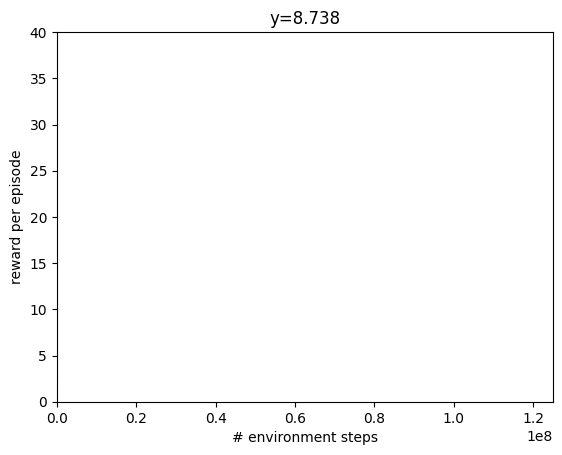

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/11141120/params.pkl


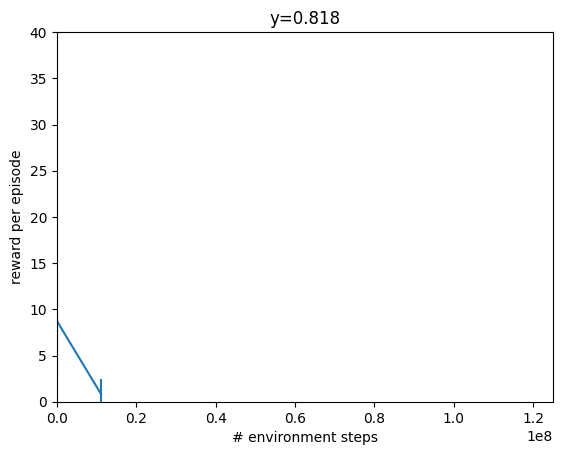

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/22282240/params.pkl


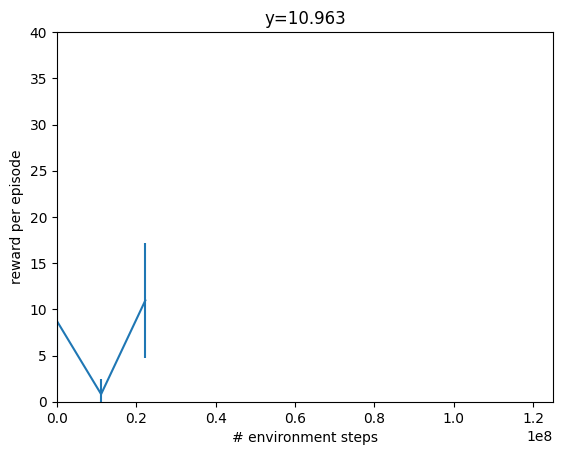

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/33423360/params.pkl


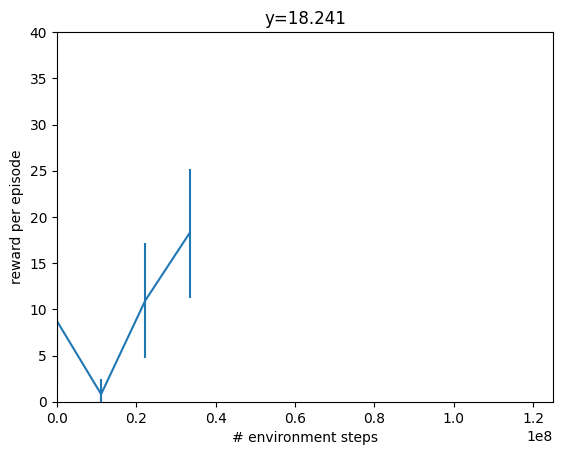

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/44564480/params.pkl


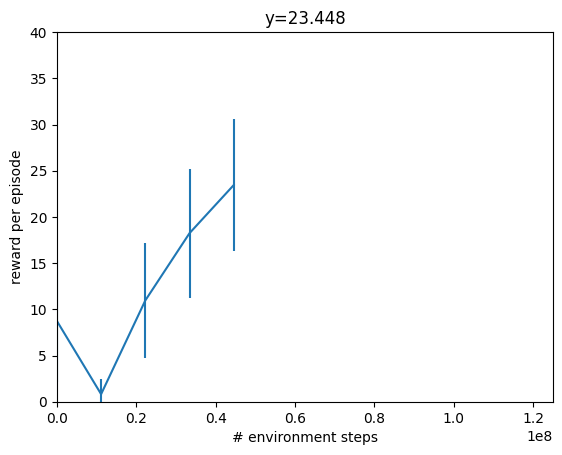

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/55705600/params.pkl


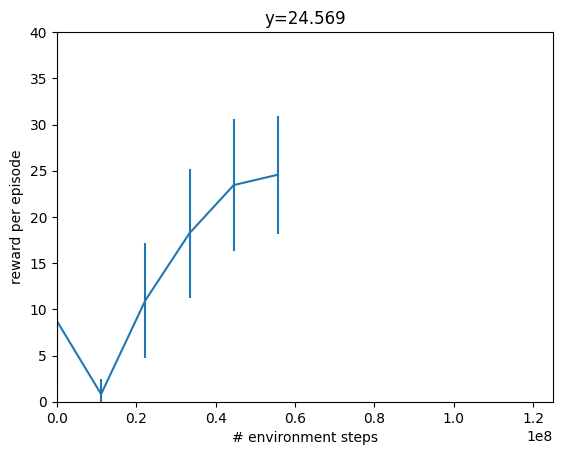

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/66846720/params.pkl


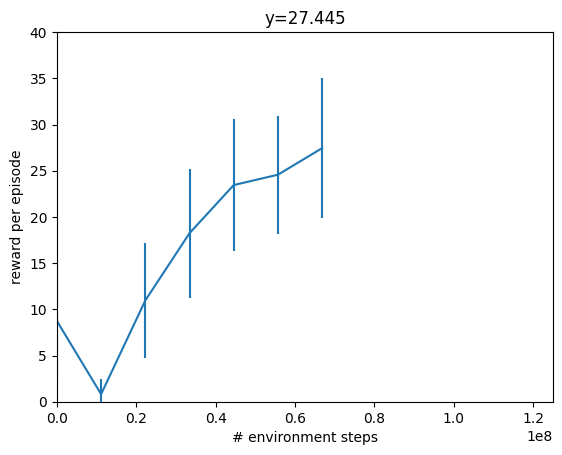

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/77987840/params.pkl


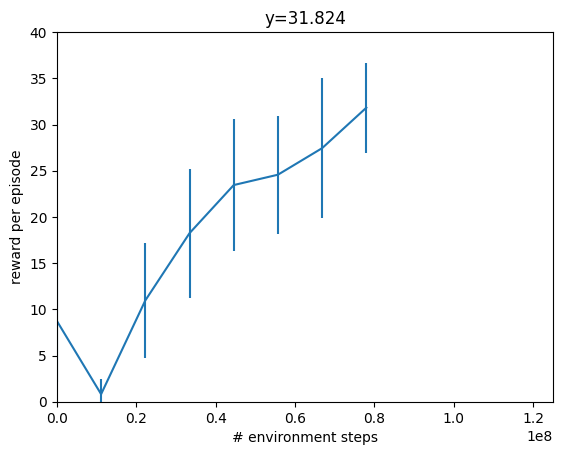

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/89128960/params.pkl


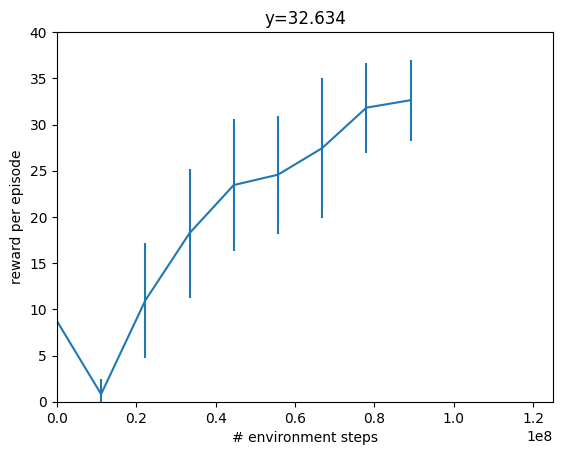

Successfully saved /mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts/100270080/params.pkl


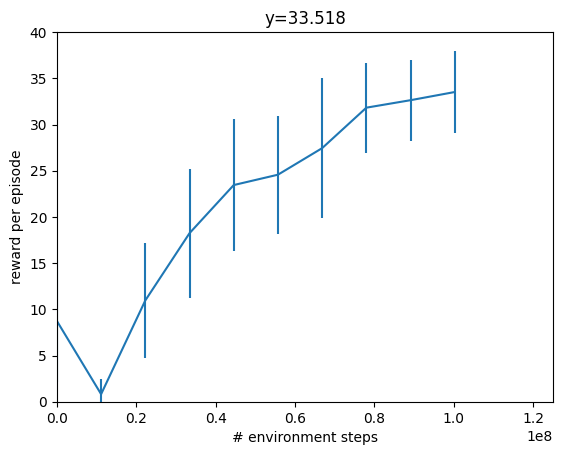

time to jit: 0:00:59.488135
time to train: 0:08:47.216718


In [48]:
import pickle

ckpt_path = epath.Path('/mnt/d/project_pupper/mujoco/mujoco_playground/quadrupred_joystick/ckpts')
ckpt_path.mkdir(parents=True, exist_ok=True)

def policy_params_fn(current_step, make_policy, params):
  # save checkpoints
  orbax_checkpointer = ocp.PyTreeCheckpointer()
  save_args = orbax_utils.save_args_from_target(params)
  path = ckpt_path / f'{current_step}'
  orbax_checkpointer.save(path, params, force=True, save_args=save_args)
  path_pkl = path / 'params.pkl'
  with open(path_pkl, 'wb') as f:
      pickle.dump(params, f)
  print(f"Successfully saved {path_pkl}")


make_networks_factory = functools.partial(
    ppo_networks.make_ppo_networks,
        policy_hidden_layer_sizes=(128, 128, 128, 128))
train_fn = functools.partial(
      ppo.train, num_timesteps=100_000_000, num_evals=10,
      reward_scaling=1, episode_length=1000, normalize_observations=True,
      action_repeat=1, unroll_length=20, num_minibatches=32,
      num_updates_per_batch=4, discounting=0.97, learning_rate=3.0e-4,
      entropy_cost=1e-2, num_envs=8192, batch_size=256,
      network_factory=make_networks_factory,
      randomization_fn=domain_randomize,
      policy_params_fn=policy_params_fn,
      seed=0)

x_data = []
y_data = []
ydataerr = []
times = [datetime.now()]
max_y, min_y = 40, 0

def progress(num_steps, metrics):
  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics['eval/episode_reward'])
  ydataerr.append(metrics['eval/episode_reward_std'])

  plt.xlim([0, train_fn.keywords['num_timesteps'] * 1.25])
  plt.ylim([min_y, max_y])

  plt.xlabel('# environment steps')
  plt.ylabel('reward per episode')
  plt.title(f'y={y_data[-1]:.3f}')

  plt.errorbar(
      x_data, y_data, yerr=ydataerr)
  plt.show()

# Reset environments since internals may be overwritten by tracers from the
# domain randomization function.
env = envs.get_environment(env_name)
eval_env = envs.get_environment(env_name)
make_inference_fn, params, _= train_fn(environment=env,
                                       progress_fn=progress,
                                       eval_env=eval_env)

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')



In [49]:
# Save and reload params.
model_path = 'pupper_model/mjx_brax_quadruped_policy'
model.save_params(model_path, params)
params = model.load_params(model_path)

inference_fn = make_inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

In [50]:
eval_env = envs.get_environment(env_name)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

In [11]:
# @markdown Commands **only used for Barkour Env**:
x_vel = 0.  #@param {type: "number"}
y_vel = -1  #@param {type: "number"}(-y為正向)
ang_vel = 0  #@param {type: "number"}

the_command = jp.array([x_vel, y_vel, ang_vel])

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
state.info['command'] = the_command
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

media.show_video(
    eval_env.render(rollout[::render_every], camera='track', width=640, height=480),
    fps=1.0 / eval_env.dt / render_every)

2025-06-15 01:39:29.472154: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


This browser does not support the video tag.


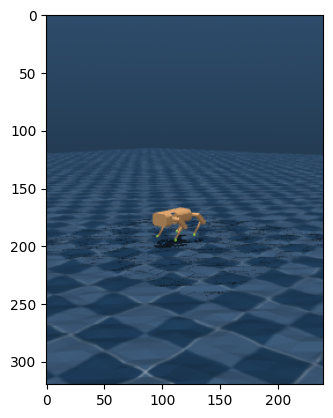

In [165]:
# use the height field scene
scene_file = 'scene_hfield_mjx.xml'

env = envs.get_environment(env_name, scene_file=scene_file)
jit_reset = jax.jit(env.reset)
state = jit_reset(jax.random.PRNGKey(0))
plt.imshow(env.render([state.pipeline_state], camera='track')[0])

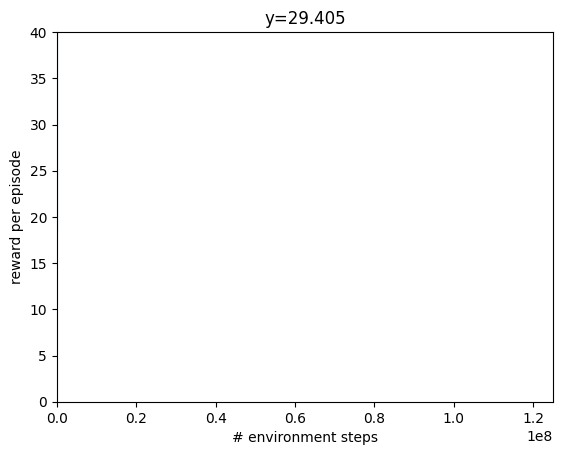

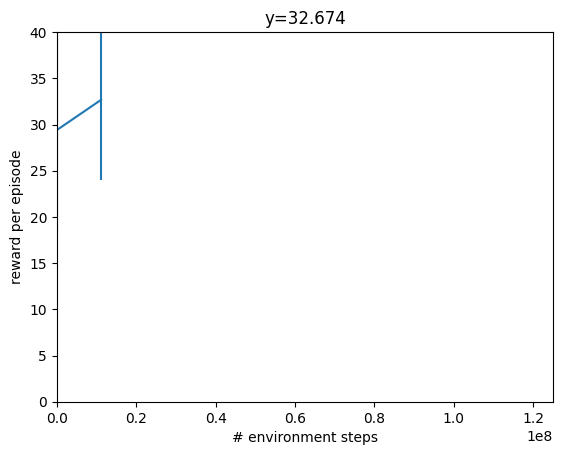

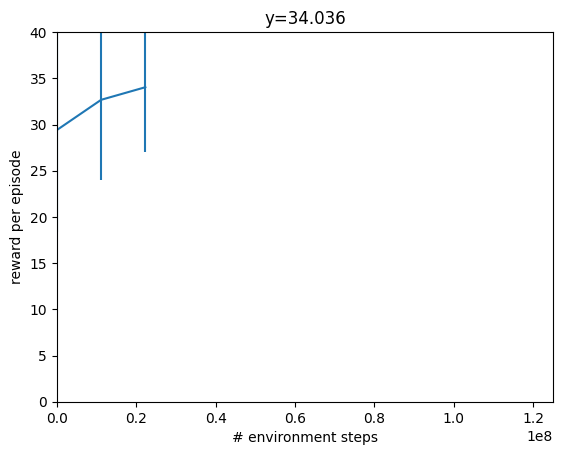

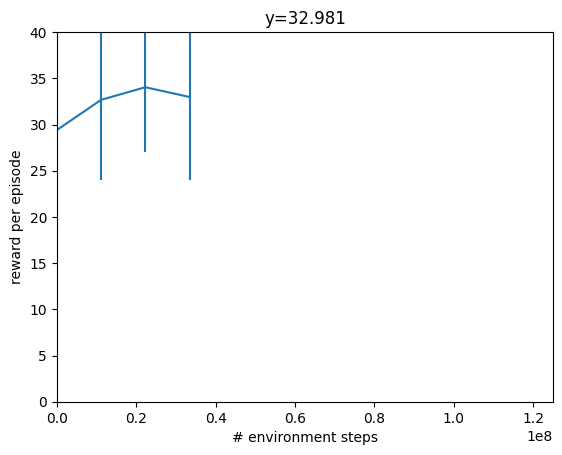

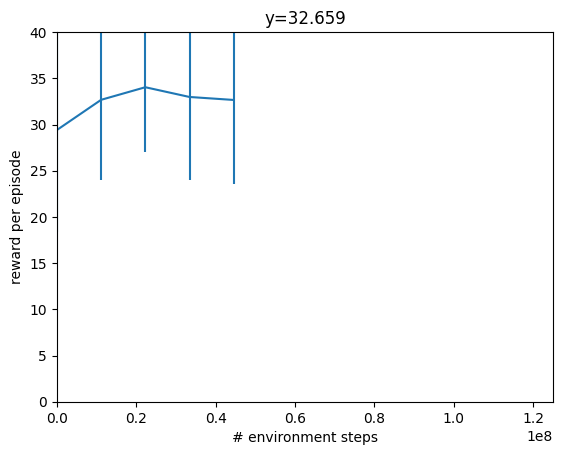

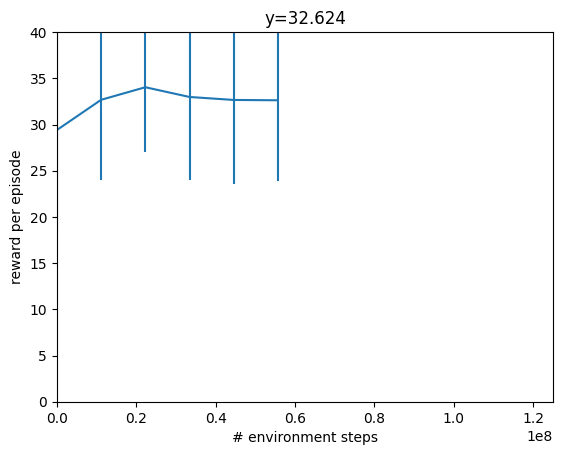

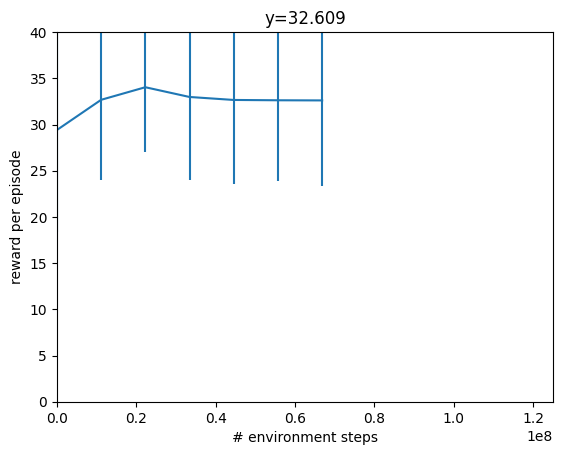

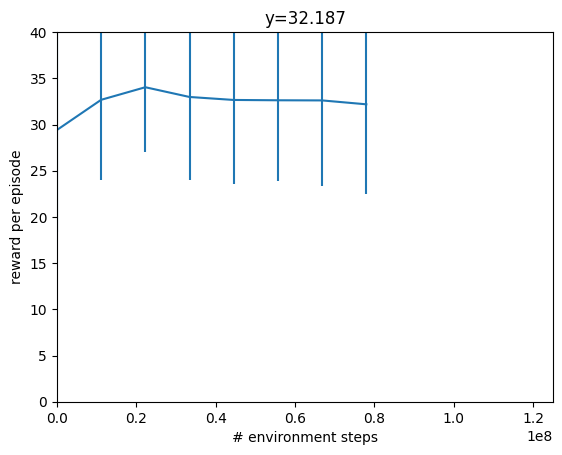

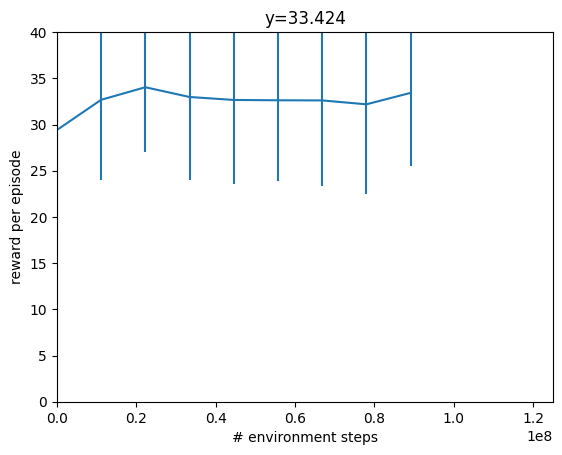

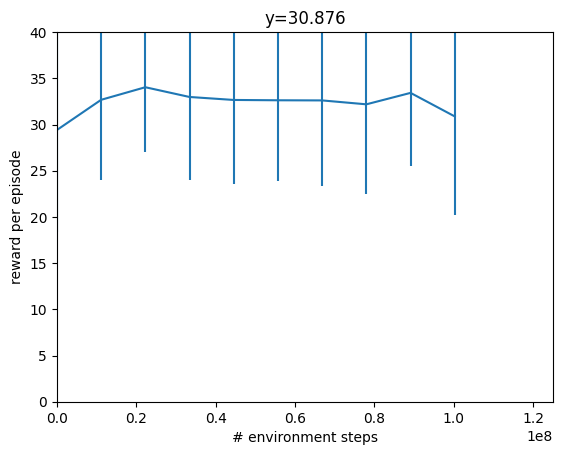

time to jit: 0:01:13.027107
time to train: 0:12:19.246439


In [166]:
# grab the latest checkpoint from the flat terrain joystick policy
latest_ckpts = list(ckpt_path.glob('*'))
latest_ckpts.sort(key=lambda x: int(x.as_posix().split('/')[-1]))
latest_ckpt = latest_ckpts[-1]


train_fn = functools.partial(
      ppo.train, num_timesteps=100_000_000, num_evals=10,
      reward_scaling=1, episode_length=1000, normalize_observations=True,
      action_repeat=1, unroll_length=20, num_minibatches=32,
      num_updates_per_batch=4, discounting=0.97, learning_rate=3.0e-4,
      entropy_cost=1e-2, num_envs=8192, batch_size=256,
      network_factory=make_networks_factory,
      randomization_fn=domain_randomize, seed=0,
      restore_checkpoint_path=latest_ckpt)

x_data = []
y_data = []
ydataerr = []
times = [datetime.now()]
max_y, min_y = 40, 0

# Reset environments since internals may be overwritten by tracers from the
# domain randomization function.
env = envs.get_environment(env_name, scene_file=scene_file)
eval_env = envs.get_environment(env_name, scene_file=scene_file)
make_inference_fn, params, _= train_fn(environment=env,
                                       progress_fn=progress,
                                       eval_env=eval_env)

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')

In [167]:
eval_env = envs.get_environment(env_name, scene_file=scene_file)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
inference_fn = make_inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

In [168]:
# @markdown Commands **only used for Barkour Env**:
x_vel = 0  #@param {type: "number"}
y_vel = -0.5  #@param {type: "number"}
ang_vel = 0  #@param {type: "number"}

the_command = jp.array([x_vel, y_vel, ang_vel])

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
state.info['command'] = the_command
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

media.show_video(
    eval_env.render(rollout[::render_every], camera='track', width=640, height=480),
    fps=1.0 / eval_env.dt / render_every)

This browser does not support the video tag.


Jax 轉 onnx 模型

In [ ]:
print(network_params_dict)

NameError: name 'preprocessor_params' is not defined

In [ ]:
'''
# ================================================================
# ===         JAX Pupper Policy to ONNX Conversion Script        ===
# ================================================================

# --- 導入所有必要的函式庫 ---
import functools
import numpy as np
import pickle
import jax
import tensorflow as tf
from tensorflow.keras import layers
import tf2onnx

# 導入我們需要的 Brax 和自訂環境組件
from brax.training.agents.ppo import networks as ppo_networks

print("--- Starting JAX to ONNX Conversion Process ---")

# --- Step 1: 實例化環境以獲取真實參數 ---
print("\nStep 1: Initializing PupperEnv to get model parameters...")
try:
    # 註冊您的自訂環境，如果還沒註冊的話
    if 'pupper' not in envs._envs:
        envs.register_environment('pupper', PupperEnv)
    
    # 創建環境實例，它會自己載入 XML 並設定好所有參數
    # 我們需要提供一個 scene_file，即使它只是為了初始化
    env = envs.get_environment('pupper', scene_file='scene_mjx.xml')
    
    observation_size = env.observation_size
    action_size = env.action_size
    print(f"  - Successfully fetched from env: obs_size={observation_size}, act_size={action_size}")
except Exception as e:
    print(f"Error initializing environment: {e}")
    # 如果環境初始化失敗，我們使用手動定義的後備值
    observation_size = 31
    action_size = 12
    print(f"  - Using fallback values: obs_size={observation_size}, act_size={action_size}")


# --- Step 2: 載入訓練好的 JAX 權重 ---
# 指向您用 pickle 保存的、包含完整元組的 params.pkl
ckpt_path = "quadrupred_joystick/ckpts/100270080/params.pkl" 

print(f"\nStep 2: Loading JAX parameters from: {ckpt_path}")
with open(ckpt_path, 'rb') as f:
    # 載入的 params 是一個元組: (normalizer_object, network_params_dict)
    params = pickle.load(f)

# 根據我們最終的診斷，分離出正規化器和網路權重
normalizer_object = params[0]
network_params_dict = params[1]
print("  - JAX parameters loaded successfully.")


# --- Step 3: 創建一個等效的 TensorFlow Keras 模型 ---
print("\nStep 3: Building equivalent TensorFlow Keras model...")

# 定義與 Brax MLP 結構對應的 Keras MLP 模型
class MLP(tf.keras.Model):
    def __init__(self, layer_sizes, activation=tf.nn.swish, name='mlp_block', **kwargs):
        super().__init__(name=name)
        self.mlp_block = tf.keras.Sequential(name="MLP_0")
        for i, size in enumerate(layer_sizes):
            # 輸出層不使用激活函式
            act = activation if i < len(layer_sizes) - 1 else None
            self.mlp_block.add(layers.Dense(
                size, activation=act, kernel_initializer='lecun_uniform', name=f"hidden_{i}"
            ))
    def call(self, inputs):
        return self.mlp_block(inputs)

# 定義一個工廠函式來創建完整的策略網路，包含正規化層
def make_tf_policy_network(obs_size, act_size, hidden_sizes, normalizer_mean, normalizer_std):
    # 1. 輸入層
    inputs = tf.keras.Input(shape=(obs_size,), name='obs')
    
    # 2. 正規化
    mean_tensor = tf.constant(normalizer_mean, dtype=tf.float32)
    std_tensor = tf.constant(normalizer_std, dtype=tf.float32)
    normalized_obs = (inputs - mean_tensor) / (std_tensor + 1e-8)
    
    # 3. MLP 主體
    mlp = MLP(layer_sizes=list(hidden_sizes) + [act_size * 2])
    logits = mlp(normalized_obs)
    
    # 4. 使用 Lambda 層來包裝 tf.split
    #    這個 Lambda 層會接收 logits 作為輸入，並輸出 loc
    loc = layers.Lambda(lambda x: tf.split(x, 2, axis=-1)[0], name='split_mean')(logits)
    
    # 5. 輸出層
    outputs = tf.keras.layers.Activation('tanh', name='actions')(loc)
    
    # 6. 創建並返回完整的 Keras 模型
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# === 核心修正 #1：使用字典鍵來獲取 mean 和 std ===
print("  - Extracting normalizer statistics from dictionary...")
mean = np.array(normalizer_object.mean)
std = np.array(normalizer_object.std)
print(f"    - Mean shape: {mean.shape}, Std shape: {std.shape}")
# ===============================================

# 創建 TF 模型
tf_policy_network = make_tf_policy_network(
    obs_size=observation_size,
    act_size=action_size,
    hidden_sizes=(128, 128, 128, 128),
    normalizer_mean=mean,
    normalizer_std=std
)
print("  - TensorFlow Keras model built successfully.")
tf_policy_network.summary()


# --- Step 4: 將 JAX 權重手動轉移到 TensorFlow 模型 ---
print("\nStep 4: Transferring JAX weights to TensorFlow model...")

def transfer_weights(jax_weights_dict, tf_model):
    """
    接收已經是 {hidden_0: ...} 結構的字典，並轉移權重。
    """
    tf_mlp_layers = tf_model.get_layer('mlp_block').layers
    for i, layer in enumerate(tf_mlp_layers):
        if isinstance(layer, layers.Dense):
            layer_name = f"hidden_{i}"
            if layer_name in jax_weights_dict:
                jax_layer_params = jax_weights_dict[layer_name]
                kernel = np.array(jax_layer_params['kernel'])
                bias = np.array(jax_layer_params['bias'])
                print(f"  - Transferring to layer '{layer.name}': kernel {kernel.shape}, bias {bias.shape}")
                layer.set_weights([kernel, bias])

# 我們需要的是 'policy' 裡面的內容
weights_dict_for_transfer = network_params_dict['params']
transfer_weights(weights_dict_for_transfer, tf_policy_network)
# ========================================================
print("  - Weight transfer complete.")



# --- Step 5: 將 TensorFlow 模型轉換為 ONNX ---
print("\nStep 5: Converting TensorFlow model to ONNX...")
output_path = "quadruped_policy.onnx"
# 輸入簽名使用我們從環境中獲取的、正確的 obs_size
spec = [tf.TensorSpec(shape=(None, observation_size), dtype=tf.float32, name="obs")]

model_proto, _ = tf2onnx.convert.from_keras(
    tf_policy_network, 
    input_signature=spec, 
    opset=13, # 使用一個較新的 opset 版本以獲得更好的相容性
    output_path=output_path
)

print(f"\nConversion successful! ONNX model saved to: {output_path}")
print("This file is now ready for deployment in your Sim2Real script.")'''

--- Starting JAX to ONNX Conversion Process ---

Step 1: Initializing PupperEnv to get model parameters...
  - Successfully fetched from env: obs_size=465, act_size=12

Step 2: Loading JAX parameters from: quadrupred_joystick/ckpts/100270080/params.pkl
  - JAX parameters loaded successfully.

Step 3: Building equivalent TensorFlow Keras model...
  - Extracting normalizer statistics from dictionary...
    - Mean shape: (465,), Std shape: (465,)
  - TensorFlow Keras model built successfully.


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ obs (InputLayer)                │ (None, 465)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 465)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 465)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_block (MLP)                 │ (None, 24)             │       112,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ split_mean (Lambda)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ actions (Activation)            │ (None, 12)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,280 (438.59 KB)

 Trainable params: 112,280 (438.59 KB)

 Non-trainable params: 0 (0.00 B)


Step 4: Transferring JAX weights to TensorFlow model...
  - Weight transfer complete.

Step 5: Converting TensorFlow model to ONNX...


I0000 00:00:1750016859.934600  628551 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1750016859.934824  628551 single_machine.cc:374] Starting new session
I0000 00:00:1750016859.935412  628551 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2314 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1750016860.002652  628551 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2314 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1750016860.021385  628551 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1750016860.021686  628551 single_machine.cc:374] Starting new session
I0000 00:00:1750016860.022404  628551 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:


Conversion successful! ONNX model saved to: quadruped_policy.onnx
This file is now ready for deployment in your Sim2Real script.


In [ ]:
# ==============================================================================
# === JAX (Brax/Orbax) to ONNX Conversion Script (with Normalization)      ===
# ==============================================================================

# --- 導入所有必要的函式庫 ---
import functools
import numpy as np
import jax
import tensorflow as tf
from tensorflow.keras import layers
import tf2onnx
from pathlib import Path
import orbax.checkpoint as ocp # <--- 使用 Orbax 載入

# 導入 Brax 網路，因為我們需要它的結構信息
from brax.training.agents.ppo import networks as ppo_networks

print("--- Starting JAX (Orbax) to ONNX Conversion Process ---")

# --- Step 1: 定義模型參數 ---
# 這些參數必須與您的訓練環境完全匹配
OBSERVATION_SIZE = 31 * 15
ACTION_SIZE = 12
POLICY_HIDDEN_LAYER_SIZES = (128, 128, 128, 128)

# --- Step 2: 從 Orbax Checkpoint 載入訓練好的 JAX 參數 ---
# 指向您訓練時儲存的 checkpoint 目錄和步驟
CKPT_PARENT_DIR = Path("quadrupred_joystick/ckpts") # <--- 請確認這是您的父目錄
absolute_parent_dir = CKPT_PARENT_DIR.resolve()
STEP_TO_LOAD = "100270080" # <--- 請確認這是您要轉換的步驟
ckpt_path = absolute_parent_dir / STEP_TO_LOAD

print(f"\nStep 1: Loading JAX parameters from Orbax checkpoint: {ckpt_path}")
try:
    checkpointer = ocp.PyTreeCheckpointer()
    # 載入的 params 是一個字典: {'preprocessor': ..., 'policy': ...}
    params = checkpointer.restore(ckpt_path)
    
    # === 核心修正：使用列表索引來分離參數 ===
    # 根據錯誤訊息，我們推斷 params 是一個列表或元組
    # 按照 Brax 的慣例，第一個元素通常是正規化器參數，第二個是策略網路參數
    if isinstance(params, (list, tuple)) and len(params) == 2:
        print("  - Detected params as a list/tuple. Separating by index.")
        preprocessor_params = params[0]
        policy_params = params[1]
        
        # 我們仍然需要確認 preprocessor_params 內部是一個字典
        # 因為 running_statistics.normalize 需要 'mean' 和 'std' 鍵
        assert 'mean' in preprocessor_params and 'std' in preprocessor_params, \
            "The first element of params is not a valid preprocessor object."
            
    elif isinstance(params, dict) and 'preprocessor' in params and 'policy' in params:
        print("  - Detected params as a dictionary. Separating by key.")
        preprocessor_params = params['preprocessor']
        policy_params = params['policy']
    
    else:
        # 如果結構既不是預期的列表也不是預期的字典，則拋出錯誤
        print(f"  [ERROR] Loaded params has an unexpected structure. Type: {type(params)}")
        # 為了調試，打印出結構
        jax.debug.print("Loaded params structure: {}", params)
        raise TypeError("Cannot determine how to separate preprocessor and policy params.")
    
    print("  - JAX parameters loaded and separated successfully.")
    # ===============================================
    
    # 提取正規化統計數據
    # 現在 preprocessor_params 是一個字典 {'mean': ..., 'std': ...}
    mean = np.array(preprocessor_params['mean'])
    std = np.array(preprocessor_params['std'])
    
except Exception as e:
    print(f"  [ERROR] Failed to load Orbax checkpoint: {e}")
    print("  Please ensure the path is correct and you have orbax-checkpoint installed.")
    # 如果載入失敗，我們無法繼續，所以這裡直接退出或拋出錯誤
    raise e


# --- Step 3: 創建一個包含正規化層的等效 TensorFlow Keras 模型 ---
print("\nStep 2: Building equivalent TensorFlow Keras model with normalization...")

# 定義與 Brax MLP 結構對應的 Keras MLP 模型
class MLP(tf.keras.Model):
    def __init__(self, layer_sizes, activation=tf.nn.swish, name='mlp_block'):
        super().__init__(name=name)
        self.mlp_block = tf.keras.Sequential(name="MLP_body")
        for i, size in enumerate(layer_sizes):
            # Brax PPO 網路的輸出層 (logits) 不使用激活函式
            act = activation if i < len(layer_sizes) - 1 else None
            self.mlp_block.add(layers.Dense(
                size, activation=act, kernel_initializer='lecun_uniform', name=f"hidden_{i}"
            ))
    def call(self, inputs):
        return self.mlp_block(inputs)

# 定義一個工廠函式來創建完整的策略網路
def make_tf_policy_network(obs_size, act_size, hidden_sizes, normalizer_mean, normalizer_std):
    # 1. 輸入層 (給它一個明確的名字)
    inputs = tf.keras.Input(shape=(obs_size,), name='observation')
    
    # --- 核心修正：添加正規化層 ---
    # 2. 將 mean 和 std 轉換為 TensorFlow 常數
    mean_tensor = tf.constant(normalizer_mean, dtype=tf.float32)
    std_tensor = tf.constant(normalizer_std, dtype=tf.float32)
    
    # 3. 執行正規化操作
    #    加上一個很小的值以避免除以零
    normalized_obs = (inputs - mean_tensor) / (std_tensor + 1e-8)
    
    # 4. MLP 主體接收的是正規化後的觀測值
    #    Brax 的 NormalTanhDistribution 輸出 mean 和 std_dev，所以是 act_size * 2
    mlp = MLP(layer_sizes=list(hidden_sizes) + [act_size * 2])
    logits = mlp(normalized_obs)
    
    # 5. 從 logits 中分離出確定性的動作 (mean)
    #    Brax PPO 網路輸出的是 (mean, log_std)，我們只需要第一部分
    loc = layers.Lambda(lambda x: tf.split(x, num_or_size_splits=2, axis=-1)[0], name='split_loc')(logits)
    
    # 6. Brax 的 NormalTanhDistribution 最後有一個 tanh 激活
    outputs = tf.keras.layers.Activation('tanh', name='action')(loc)
    
    # 7. 創建並返回完整的 Keras 模型
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="PupperPolicy")

# 提取正規化統計數據
mean = np.array(preprocessor_params['mean'])
std = np.array(preprocessor_params['std'])

# 創建 TF 模型
tf_policy_network = make_tf_policy_network(
    obs_size=OBSERVATION_SIZE,
    act_size=ACTION_SIZE,
    hidden_sizes=POLICY_HIDDEN_LAYER_SIZES,
    normalizer_mean=mean,
    normalizer_std=std
)
print("  - TensorFlow Keras model with normalization layer built successfully.")
tf_policy_network.summary()


# --- Step 4: 將 JAX 權重手動轉移到 TensorFlow 模型 ---
print("\nStep 3: Transferring JAX weights to TensorFlow model...")

def transfer_weights(jax_policy_params, tf_model):
    # Brax PPO 網路的權重儲存在 params['NormalTanhDistribution_0'] 中
    jax_weights_dict = jax_policy_params['NormalTanhDistribution_0']
    
    # 獲取 TensorFlow 模型中的 MLP 部分
    tf_mlp_layers = tf_model.get_layer('mlp').layers[0].layers

    for i, layer in enumerate(tf_mlp_layers):
        if isinstance(layer, layers.Dense):
            layer_name_jax = f"hidden_{i}"
            jax_layer_params = jax_weights_dict[layer_name_jax]
            kernel = np.array(jax_layer_params['kernel'])
            bias = np.array(jax_layer_params['bias'])
            print(f"  - Transferring to TF layer '{layer.name}': kernel {kernel.shape}, bias {bias.shape}")
            layer.set_weights([kernel, bias])

# 執行權重轉移
transfer_weights(policy_params, tf_policy_network)
print("  - Weight transfer complete.")


# --- Step 5: 將 TensorFlow 模型轉換為 ONNX ---
print("\nStep 4: Converting TensorFlow model to ONNX...")
output_path = "quadruped_policy_normalized.onnx" # 給它一個新名字以示區別

# 輸入簽名使用我們定義的名稱 'observation'
spec = [tf.TensorSpec(shape=(None, OBSERVATION_SIZE), dtype=tf.float32, name="observation")]

model_proto, _ = tf2onnx.convert.from_keras(
    tf_policy_network, 
    input_signature=spec, 
    opset=13,
    output_path=output_path
)

print(f"\nConversion successful! ONNX model saved to: {output_path}")
print("This new model now includes the normalization step and is ready for deployment.")

SyntaxError: expected 'except' or 'finally' block (1028401172.py, line 42)